In [1]:
import math
import numpy as np
from scipy.signal import firwin, filtfilt
import torch
import matplotlib.pyplot as plt
from myPytorchModels import TimeSeriesConv as myNetMdl
from csv2numpy import prepTimeSeqData


In [2]:

# set params -------------------------------------------------------------------------------------
hzn = 0.5 # EVALUATION sample time, s
groupsize=15
numgroups=5
numgroupsunpaired=2
#fc = np.array([4,10,27,60,90]) # freq band center freqs
fc = np.array([4,10,27]) # freq band center freqs
netfile = "neural_network_pytorch_38757f70f4fc8aa0a179ee358c74212c1e790970.pth"
arfile = "neural_network_AR_38757f70f4fc8aa0a179ee358c74212c1e790970.npy"
dt_target = 0.01 # model sample time, s
seq_len = 128 # model transformer samples
hzn_len = math.ceil(hzn / dt_target)  # horizon as multiple of MODEL Ts, NOT data Ts 
filtorder = 201


In [3]:

# simpler model(s) for comparison ------------------------------------------------------

if arfile:
    Mar = np.load(arfile)
else:
    # autoregressive model for each feature
    print("Training autoregressive model for each feature...")
    _, _, _, _, _, X, Y, _, _, _, _, _, _ = prepTimeSeqData(
        seq_len=seq_len, hzn_len=1, dt_target=dt_target, drawFromStart=True, maxNumel=5e8)
    Mar = []
    for f in range(Y.shape[-1]):
        x = X[:,:,f]
        y = Y[:,0,f]
        A = np.linalg.lstsq(x, y, rcond=None)[0]
        Mar.append(A)
    Mar = np.stack(Mar, axis=1)
    del X, Y, A, x, y


In [4]:

# Prepare the Data ---------------------------------------------------------------------

#device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
device = torch.device('cpu')

fs, feature_names, feature_correction, Xs, Ys, Xb, Yb, _, YsRaw, _, YbRaw, Us, Ub = prepTimeSeqData(
    seq_len=seq_len, hzn_len=hzn_len, dt_target=dt_target, drawFromStart=False, maxNumel=1e9, omitOutliers=False)
Xs = torch.tensor(Xs, dtype=torch.float32)
Ys = torch.tensor(Ys, dtype=torch.float32)
Xb = torch.tensor(Xb, dtype=torch.float32)
Yb = torch.tensor(Yb, dtype=torch.float32)
Us = torch.tensor(Us, dtype=torch.float32)
Ub = torch.tensor(Ub, dtype=torch.float32)

filtwts = firwin(filtorder, [2, 40], pass_zero=False, fs=1/dt_target)
print(YsRaw.shape)
print(YbRaw.shape)
YsRaw = filtfilt(filtwts, 1, YsRaw, axis=0)
YbRaw = filtfilt(filtwts, 1, YbRaw, axis=0)
print(YsRaw.shape)
print(YbRaw.shape)
#YsRaw = torch.tensor(YsRaw, dtype=torch.float32)
#YbRaw = torch.tensor(YbRaw, dtype=torch.float32)

# -----------------------------------------------------------------------------------------------


Sampling frequency (Hz): 1000.0
Baseline samples used: 1167953 to 1202000
Samples used: 430953 to 465000
Baseline outliers: 0 of 34048
Data outliers: 0 of 34048
Baseline Pairs created: 32268
Input shape : (32268, 128, 165)
Output shape: (32268, 50, 165)
Event shape: (32268, 50, 1)
Main Pairs created: 32268
Input shape : (32268, 128, 165)
Output shape: (32268, 50, 165)
Event shape: (32268, 50, 1)
(32268, 50, 15)
(32268, 50, 15)
(32268, 50, 15)
(32268, 50, 15)


Total sum of all elements in Us: 31878.0


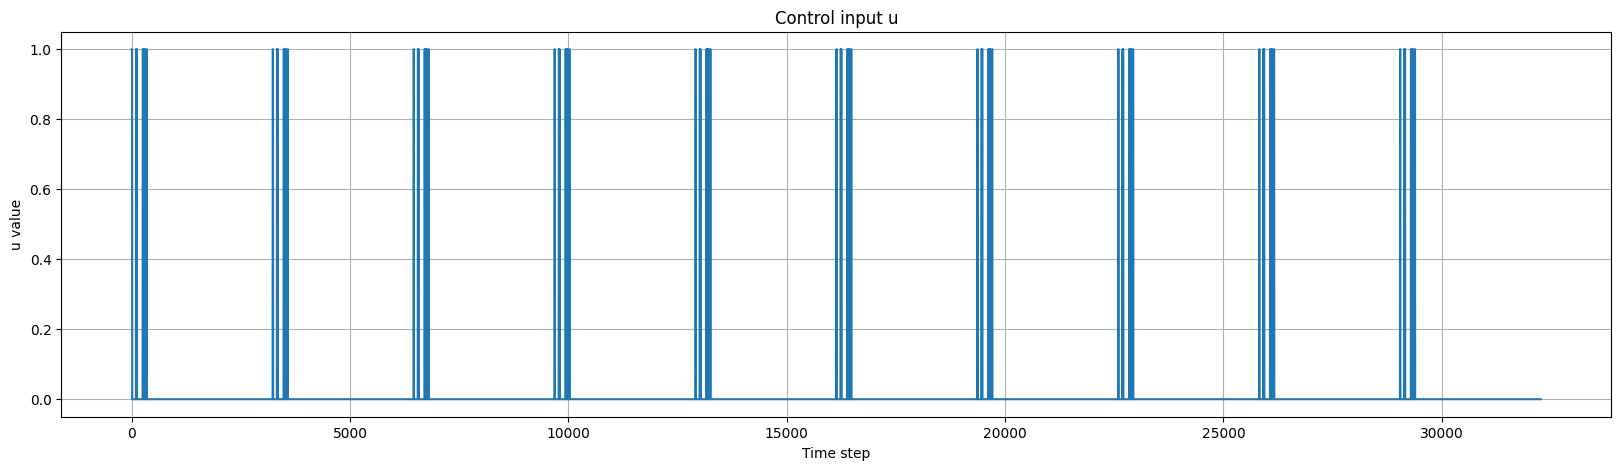

In [5]:
print(f"Total sum of all elements in Us: {torch.sum(Us).item()}")
uj = Us[:,0,-1]
# plot uj
plt.figure(figsize=(20, 5))
plt.plot(uj)
plt.title("Control input u")
plt.xlabel("Time step")
plt.ylabel("u value")
plt.grid()
plt.show()

In [6]:

# define mdl struct ====================================================================
model = myNetMdl(dim_in=Xb.shape[-1], dim_out=Yb.shape[-1], time_len=seq_len, group_size=groupsize, num_groups=numgroups, tuple_size=3, numGrpUnpaired=numgroupsunpaired)
if netfile:
    model.load_state_dict(torch.load(netfile, map_location=device))
else:
    # bias the model frequency prediction to the center of each band 
    fcenter = torch.tensor(fc, dtype=torch.float32)
    fbias = fcenter.repeat_interleave(groupsize)
    fbias = fbias*dt_target*2*math.pi # scale by model sample time and 2pi to convert to radians
    fbias = torch.atanh(fbias / (math.pi + 1e-5)) # apply inverse tanh to get bias in pre-tanh space
    with torch.no_grad():
        model.fcoFreq.bias.copy_(fbias)


In [7]:
Xs = Xb
Ys = Yb
Us = Ub

yi_true shape: (50, 165)
yi_pred shape: (50, 165)
yi_ar shape: (50, 165)


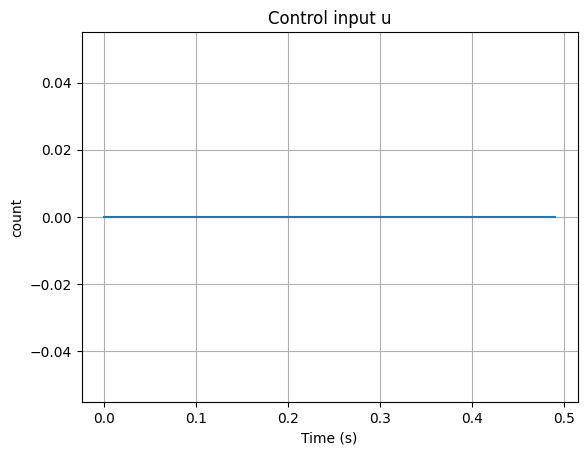

In [8]:
# example simulation 

i = 70 # batch 
xi = Xs[i:i+1,:,:].to(device)
ui = Us[i:i+1,:,:].to(device)
yi_true = Ys[i,:,:].to(device).numpy()
ytrue_recon = YsRaw[i,:,:] # unfiltered true signal for comparison
t = np.arange(yi_true.shape[0]) * dt_target

model.eval()
with torch.no_grad():
    yi_pred = model(xi, ui)
yi_pred = yi_pred[0,:,:].numpy()
ui = ui[0,:,:].numpy()

yyar = []
Xnp = Xs[i,:,:].numpy()
for _ in range(hzn_len):
    yar = []
    for f in range(Ys.shape[-1]):
        xf = Xnp[:,f]
        yarf = xf @ Mar[:,f]
        yar.append(yarf)
    yyar.append(yar)
    Xnp = np.vstack([Xnp[1:,:], np.array(yar)])
yi_ar = np.array(yyar)

print("yi_true shape:", yi_true.shape)
print("yi_pred shape:", yi_pred.shape)
print("yi_ar shape:", yi_ar.shape)

plt.figure()
plt.plot(t, ui[:, -1])
plt.title("Control input u")
plt.xlabel("Time (s)")
plt.ylabel("count")
plt.grid()
plt.show()

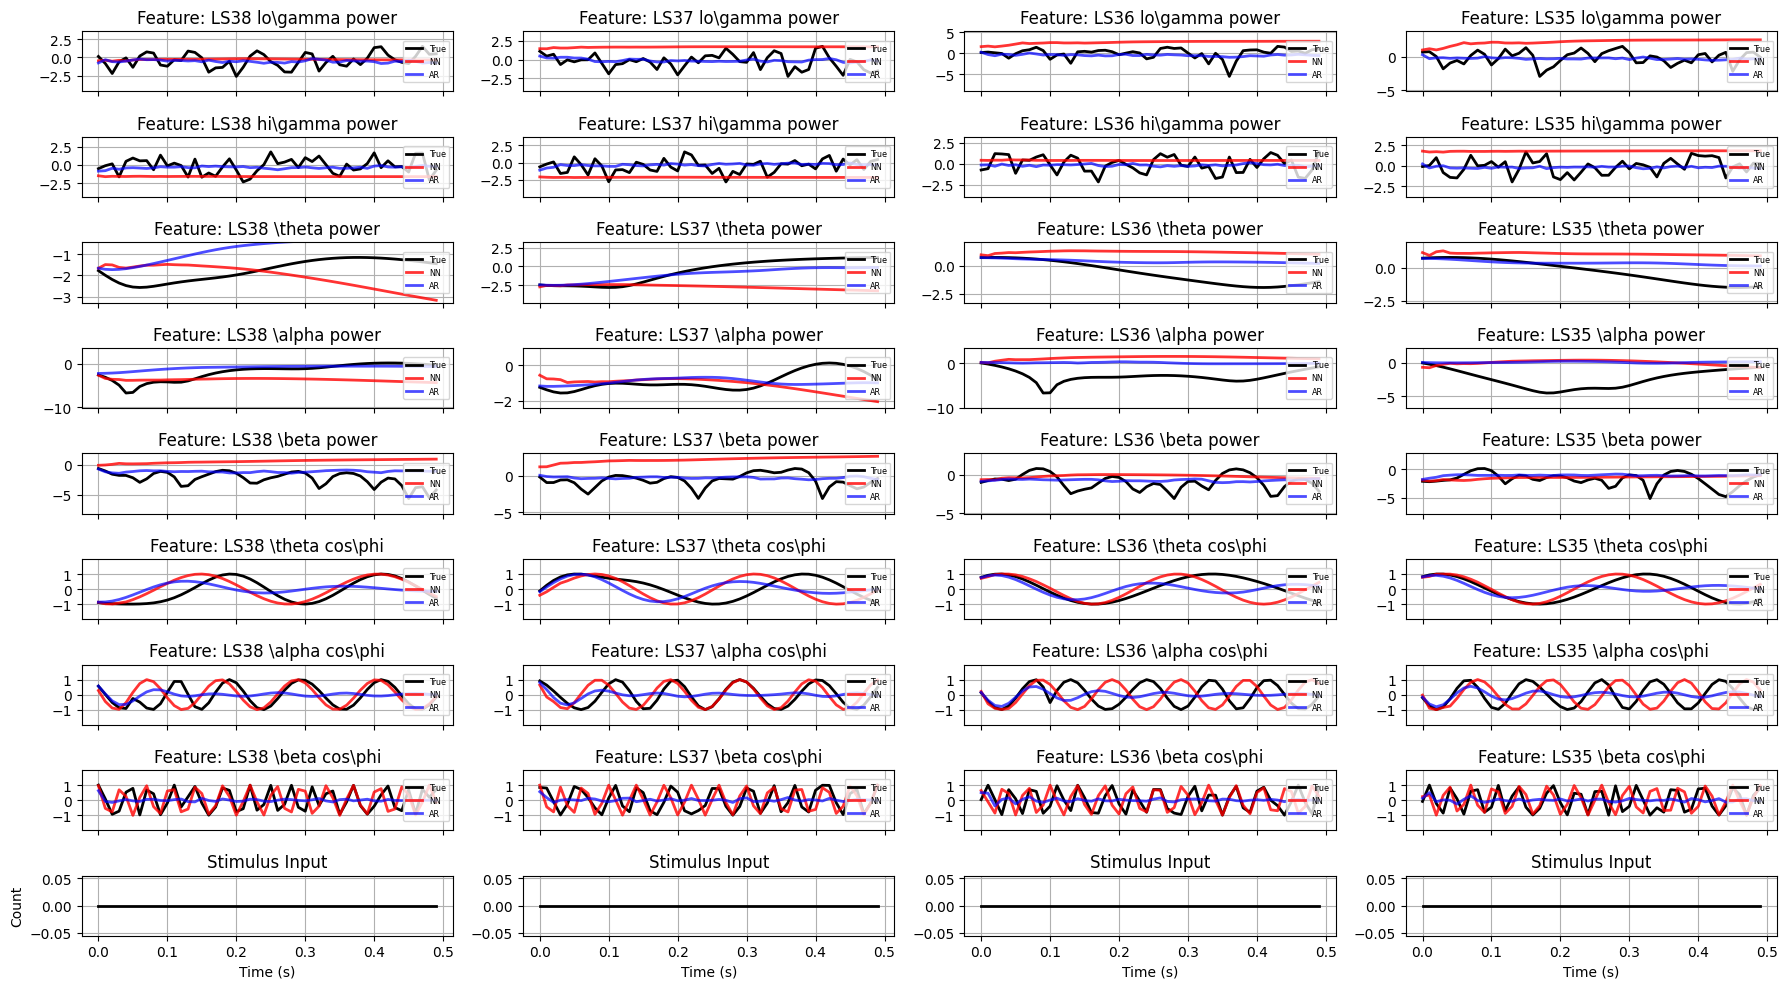

In [9]:
# choose features to display
maxNdisp = 8 # i.e. num_rows
chdisp = [7, 8, 9, 10] # index of which channel(s) to display 
num_cols = len(chdisp)

fig, axes = plt.subplots(maxNdisp+1, num_cols, sharex=True, figsize=(18, 10))
axes = np.atleast_2d(axes)

for col in range(num_cols):
    for row in range(maxNdisp):

        example_indices = np.arange(0, Xs.shape[-1], groupsize) + chdisp[col]
        example_indices = np.concatenate((
            example_indices[:(numgroups-numgroups)], 
            example_indices[-numgroupsunpaired:], 
            example_indices[2*(numgroups-numgroups):-numgroupsunpaired]), 
            axis=0)
        example_indices = example_indices[:maxNdisp]

        # feature plots 
        idx = example_indices[row]
        ax = axes[row, col]
        ax.plot(t, yi_true[:, idx], label="True", linewidth=2, color='black')
        ax.plot(t, yi_pred[:, idx], label="NN", linewidth=2, alpha=0.8, color='red')
        ax.plot(t, yi_ar[:, idx], label="AR", linewidth=2, alpha=0.7, color='blue')
        ymin = yi_true[:, idx].min()
        ymax = yi_true[:, idx].max()
        yrange = ymax - ymin
        ymin -= yrange * 0.5
        ymax += yrange * 0.5
        ax.set_ylim(ymin, ymax)
        #if col == 0:
            #ax.set_ylabel("Value")
        ax.set_title(f"Feature: {feature_names[idx]}")
        ax.legend(fontsize='xx-small', loc='right')
        ax.grid(axis='both')

    # plot stim input
    stim_ax = axes[-1, col]
    stim_ax.plot(t, ui[:,-1], linewidth=2, color='black')
    stim_ax.set_title("Stimulus Input")
    if col == 0:
        stim_ax.set_ylabel("Count")
    stim_ax.grid(axis='both')
    stim_ax.set_xlabel("Time (s)")  # Set x-label only on the last subplot

plt.tight_layout()
plt.show()

In [10]:
# recover filtered signal from processed features 
def unprocess(Y, featcorrection):
    numGrpIgnored = numgroupsunpaired # last two groups will not be used
    N = (numgroups-numGrpIgnored)*groupsize
    Ymag = Y[..., :N]
    Ycos = Y[..., N:2*N]
    Ysin = Y[..., 2*N:3*N]
    Ymag = np.sqrt(np.exp(Ymag)) * featcorrection[:(numgroups-numGrpIgnored)*groupsize]
    #Ytan = Ysin / (Ycos + np.finfo(float).eps)
    Yphase = np.arctan2(Ysin, Ycos)
    Yreal = Ymag * np.cos(Yphase)
    #Yreal = Ymag * Ycos
    return Yreal

ypred_grouped shape: (50, 3, 15)
yar_grouped shape: (50, 3, 15)
ypred_recon shape: (50, 15)
yar_recon shape: (50, 15)
ytrue_recon shape: (50, 15)


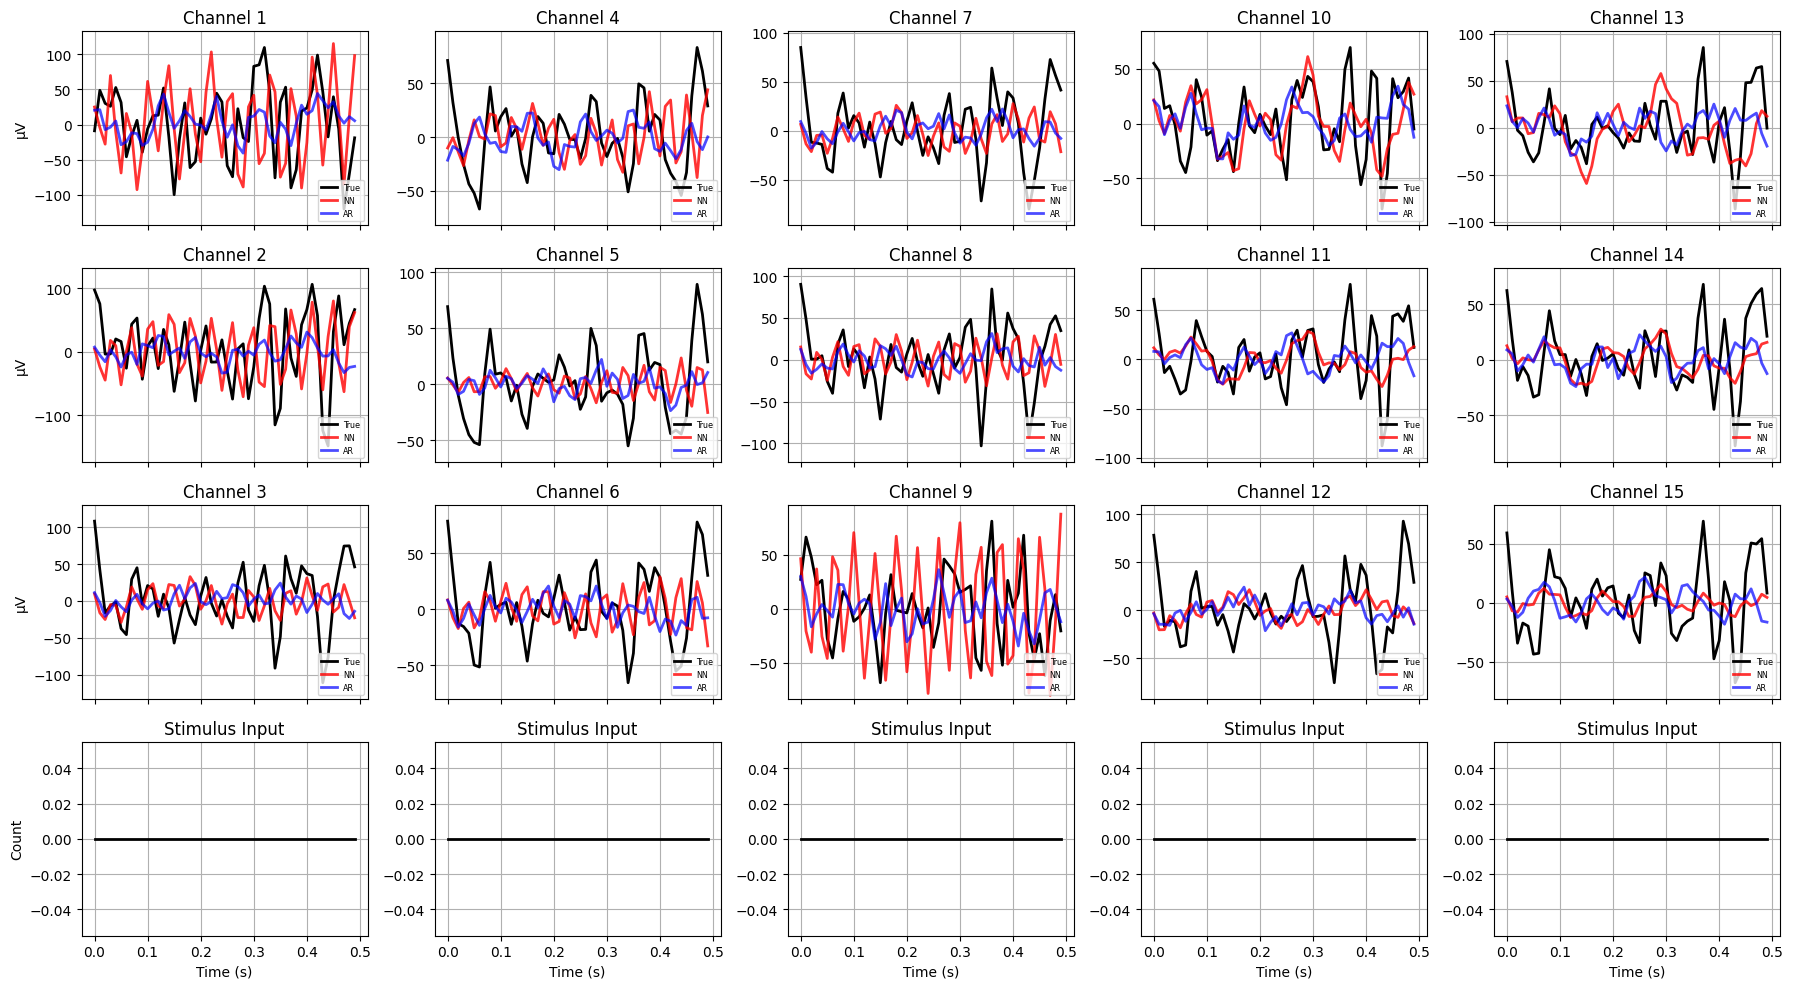

In [11]:
# channel data reconstruction
num_columns = 5
channels_per_column = 3
example_indices = np.arange(num_columns * channels_per_column)
example_indices = example_indices[example_indices < ytrue_recon.shape[1]]

ypred_grouped = unprocess(yi_pred, feature_correction)
yar_grouped = unprocess(yi_ar, feature_correction)
N = numgroups - numgroupsunpaired
ypred_grouped = ypred_grouped[..., :N*groupsize]
yar_grouped = yar_grouped[..., :N*groupsize]
ypred_grouped = ypred_grouped.reshape(-1, N, groupsize)
yar_grouped = yar_grouped.reshape(-1, N, groupsize)
print("ypred_grouped shape:", ypred_grouped.shape)
print("yar_grouped shape:", yar_grouped.shape)

ypred_recon = np.sum(ypred_grouped, axis=-2)
yar_recon = np.sum(yar_grouped, axis=-2)
print("ypred_recon shape:", ypred_recon.shape)
print("yar_recon shape:", yar_recon.shape)
print("ytrue_recon shape:", ytrue_recon.shape)

# channel plots in 5 columns by 4 rows
fig, axes = plt.subplots(channels_per_column + 1, num_columns, sharex=True, figsize=(18, 10))
axes = np.atleast_2d(axes)

for col in range(num_columns):
    for row in range(channels_per_column):
        idx = example_indices[col * channels_per_column + row]
        ax = axes[row, col]
        ax.plot(t, ytrue_recon[:, idx], label="True", linewidth=2, color='black')
        ax.plot(t, ypred_recon[:, idx], label="NN", linewidth=2, alpha=0.8, color='red')
        ax.plot(t, yar_recon[:, idx], label="AR", linewidth=2, alpha=0.7, color='blue')
        ymin = ytrue_recon[:, idx].min()
        ymax = ytrue_recon[:, idx].max()
        yrange = ymax - ymin
        ymin -= yrange * 0.1
        ymax += yrange * 0.1
        ax.set_ylim(ymin, ymax)
        if col == 0:
            ax.set_ylabel("μV")
        ax.set_title(f"Channel {idx+1}")
        ax.legend(fontsize='xx-small', loc='lower right')
        ax.grid(axis='both')

    stim_ax = axes[-1, col]
    stim_ax.plot(t, ui[:, -1], linewidth=2, color='black')
    stim_ax.set_title("Stimulus Input")
    if col == 0:
        stim_ax.set_ylabel("Count")
    stim_ax.grid(axis='both')
    stim_ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()


In [ ]:
# evaluate change over time 
ytrue_recon = np.diff(ytrue_recon, axis=0)
ypred_recon = np.diff(ypred_recon, axis=0)
yar_recon = np.diff(yar_recon, axis=0)
yi_true = np.diff(yi_true, axis=0)
yi_pred = np.diff(yi_pred, axis=0)
yi_ar = np.diff(yi_ar, axis=0)
t = t[1:]
ui = ui[1:]

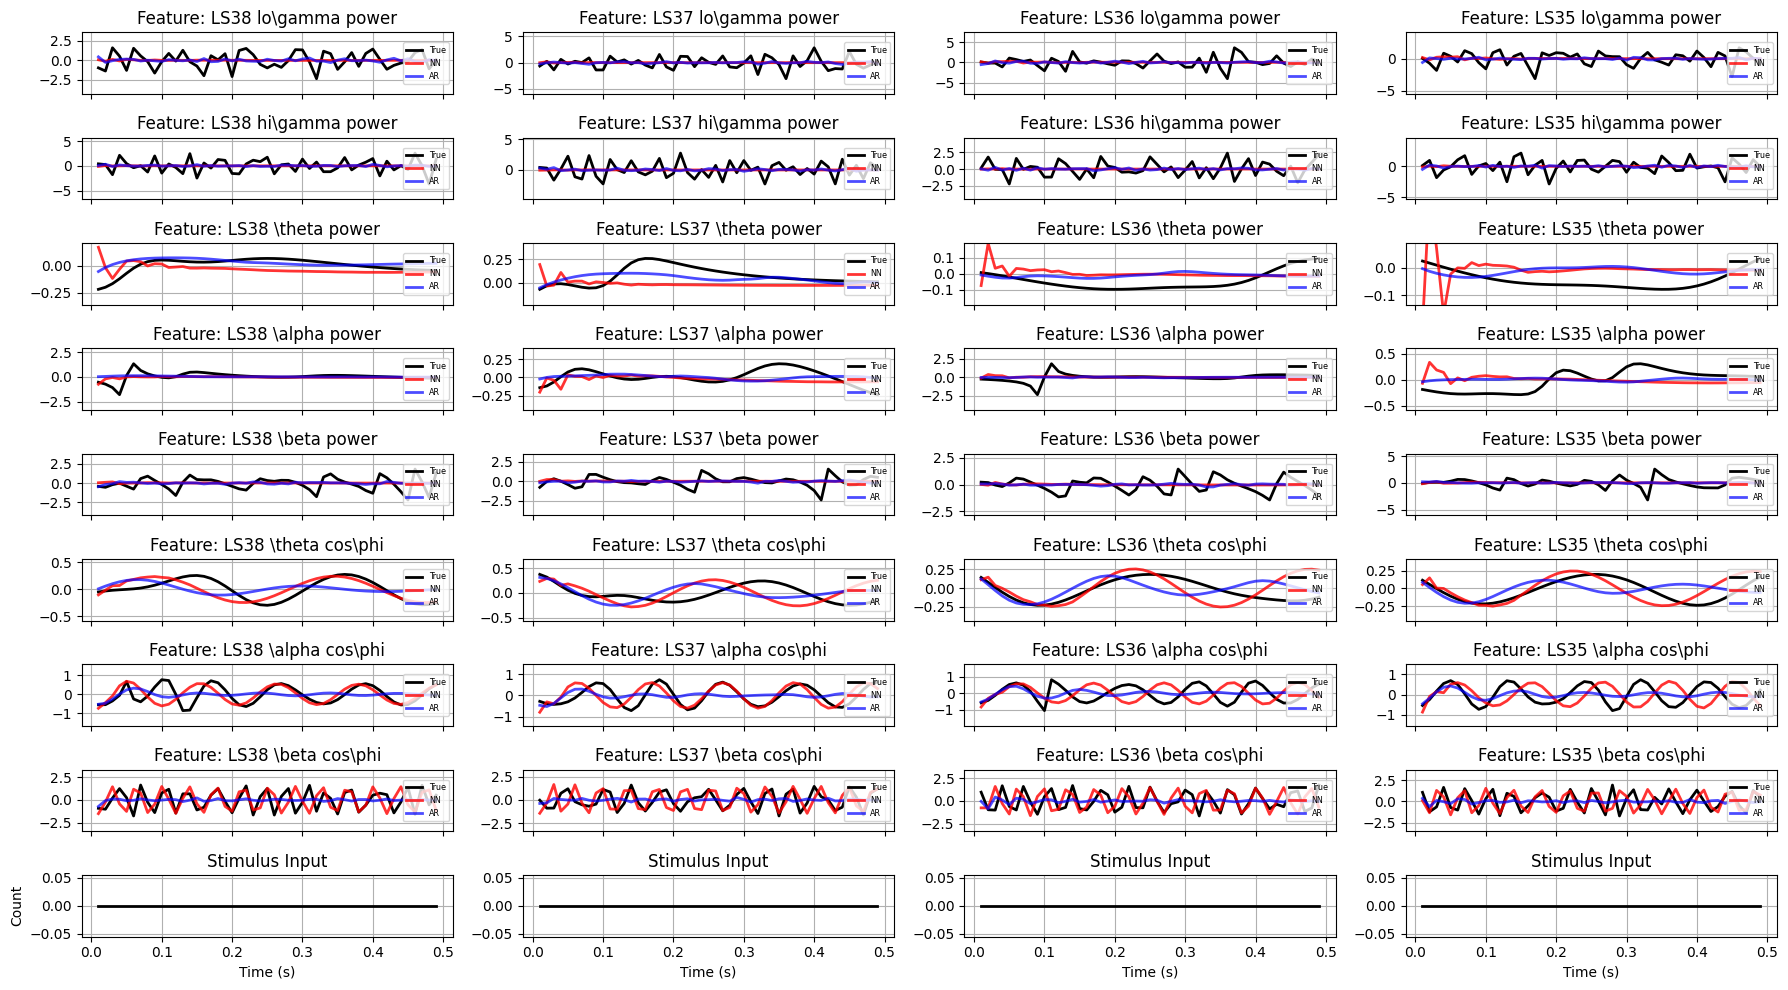

In [22]:
fig, axes = plt.subplots(maxNdisp+1, num_cols, sharex=True, figsize=(18, 10))
axes = np.atleast_2d(axes)

for col in range(num_cols):
    for row in range(maxNdisp):

        example_indices = np.arange(0, Xs.shape[-1], groupsize) + chdisp[col]
        example_indices = np.concatenate((
            example_indices[:(numgroups-numgroups)], 
            example_indices[-numgroupsunpaired:], 
            example_indices[2*(numgroups-numgroups):-numgroupsunpaired]), 
            axis=0)
        example_indices = example_indices[:maxNdisp]

        # feature plots 
        idx = example_indices[row]
        ax = axes[row, col]
        ax.plot(t, yi_true[:, idx], label="True", linewidth=2, color='black')
        ax.plot(t, yi_pred[:, idx], label="NN", linewidth=2, alpha=0.8, color='red')
        ax.plot(t, yi_ar[:, idx], label="AR", linewidth=2, alpha=0.7, color='blue')
        ymin = yi_true[:, idx].min()
        ymax = yi_true[:, idx].max()
        yrange = ymax - ymin
        ymin -= yrange * 0.5
        ymax += yrange * 0.5
        ax.set_ylim(ymin, ymax)
        #if col == 0:
            #ax.set_ylabel("Value")
        ax.set_title(f"Feature: {feature_names[idx]}")
        ax.legend(fontsize='xx-small', loc='right')
        ax.grid(axis='both')

    # plot stim input
    stim_ax = axes[-1, col]
    stim_ax.plot(t, ui[:,-1], linewidth=2, color='black')
    stim_ax.set_title("Stimulus Input")
    if col == 0:
        stim_ax.set_ylabel("Count")
    stim_ax.grid(axis='both')
    stim_ax.set_xlabel("Time (s)")  # Set x-label only on the last subplot

plt.tight_layout()
plt.show()

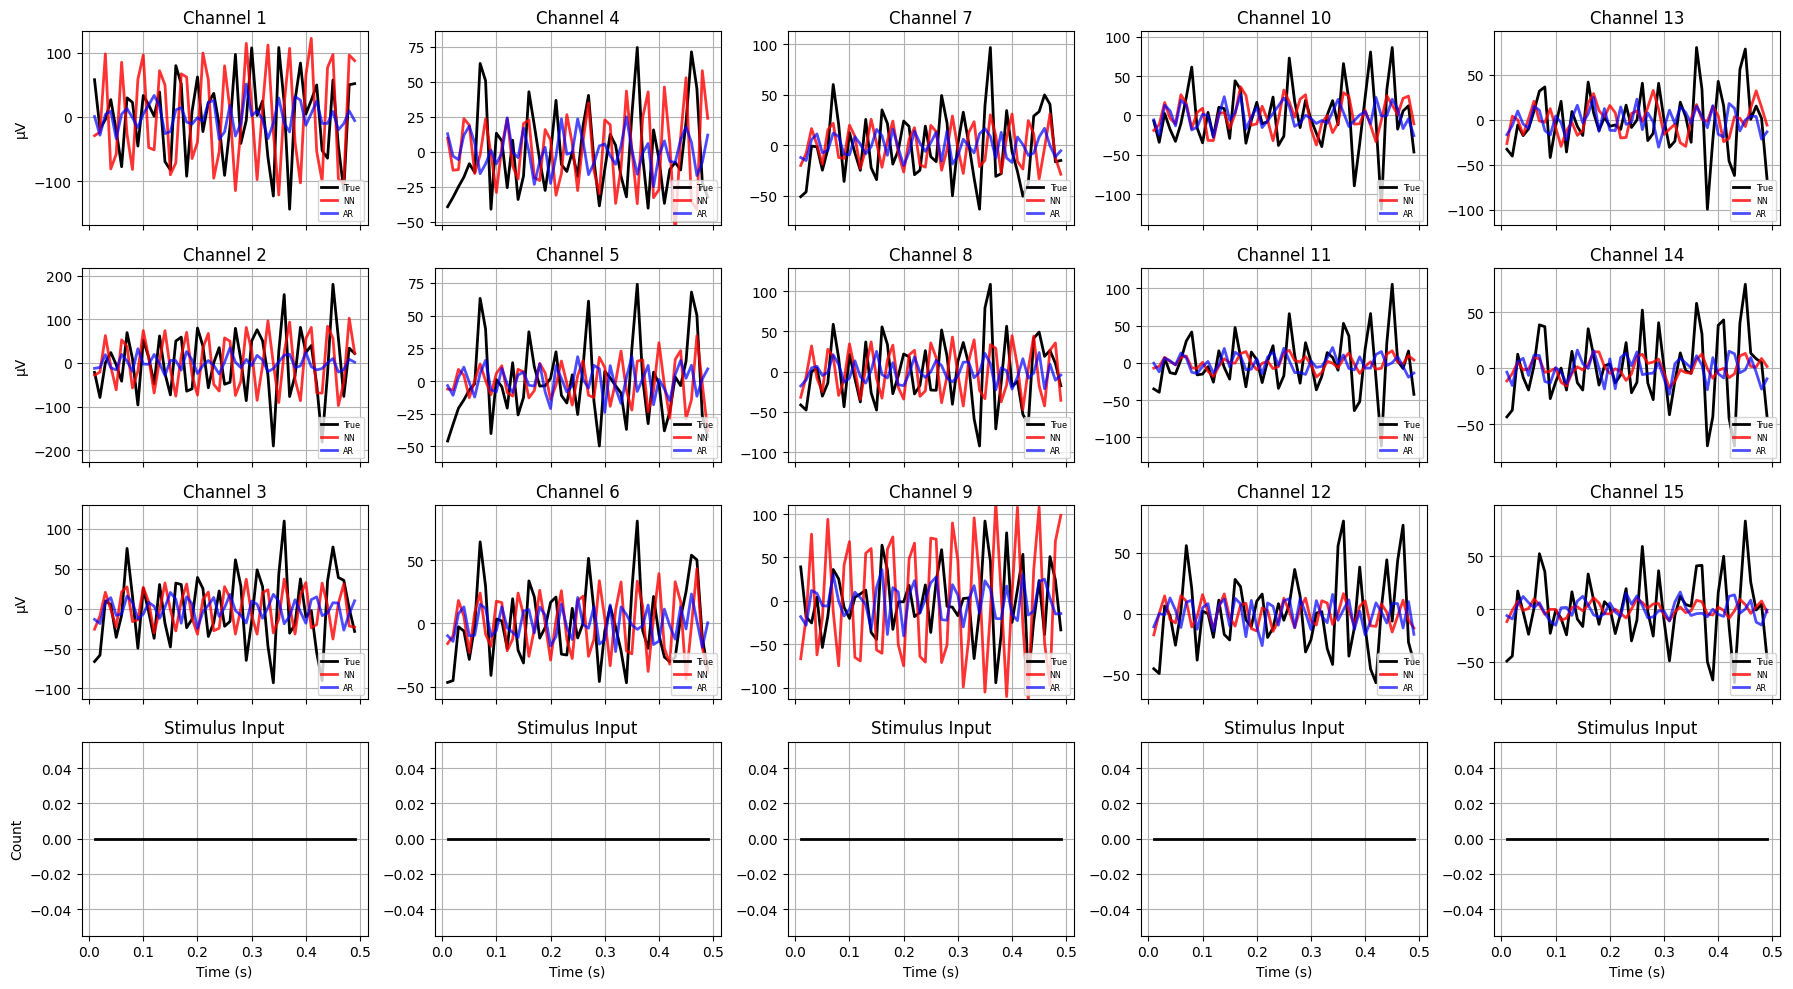

In [24]:
num_columns = 5
channels_per_column = 3
example_indices = np.arange(num_columns * channels_per_column)
example_indices = example_indices[example_indices < ytrue_recon.shape[1]]

fig, axes = plt.subplots(channels_per_column + 1, num_columns, sharex=True, figsize=(18, 10))
axes = np.atleast_2d(axes)

for col in range(num_columns):
    for row in range(channels_per_column):
        idx = example_indices[col * channels_per_column + row]
        ax = axes[row, col]
        ax.plot(t, ytrue_recon[:, idx], label="True", linewidth=2, color='black')
        ax.plot(t, ypred_recon[:, idx], label="NN", linewidth=2, alpha=0.8, color='red')
        ax.plot(t, yar_recon[:, idx], label="AR", linewidth=2, alpha=0.7, color='blue')
        ymin = ytrue_recon[:, idx].min()
        ymax = ytrue_recon[:, idx].max()
        yrange = ymax - ymin
        ymin -= yrange * 0.1
        ymax += yrange * 0.1
        ax.set_ylim(ymin, ymax)
        if col == 0:
            ax.set_ylabel("μV")
        ax.set_title(f"Channel {idx+1}")
        ax.legend(fontsize='xx-small', loc='lower right')
        ax.grid(axis='both')

    stim_ax = axes[-1, col]
    stim_ax.plot(t, ui[:, -1], linewidth=2, color='black')
    stim_ax.set_title("Stimulus Input")
    if col == 0:
        stim_ax.set_ylabel("Count")
    stim_ax.grid(axis='both')
    stim_ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()